# Cleaned_data (ingredient_merged2) 기준으로 청크화 하기

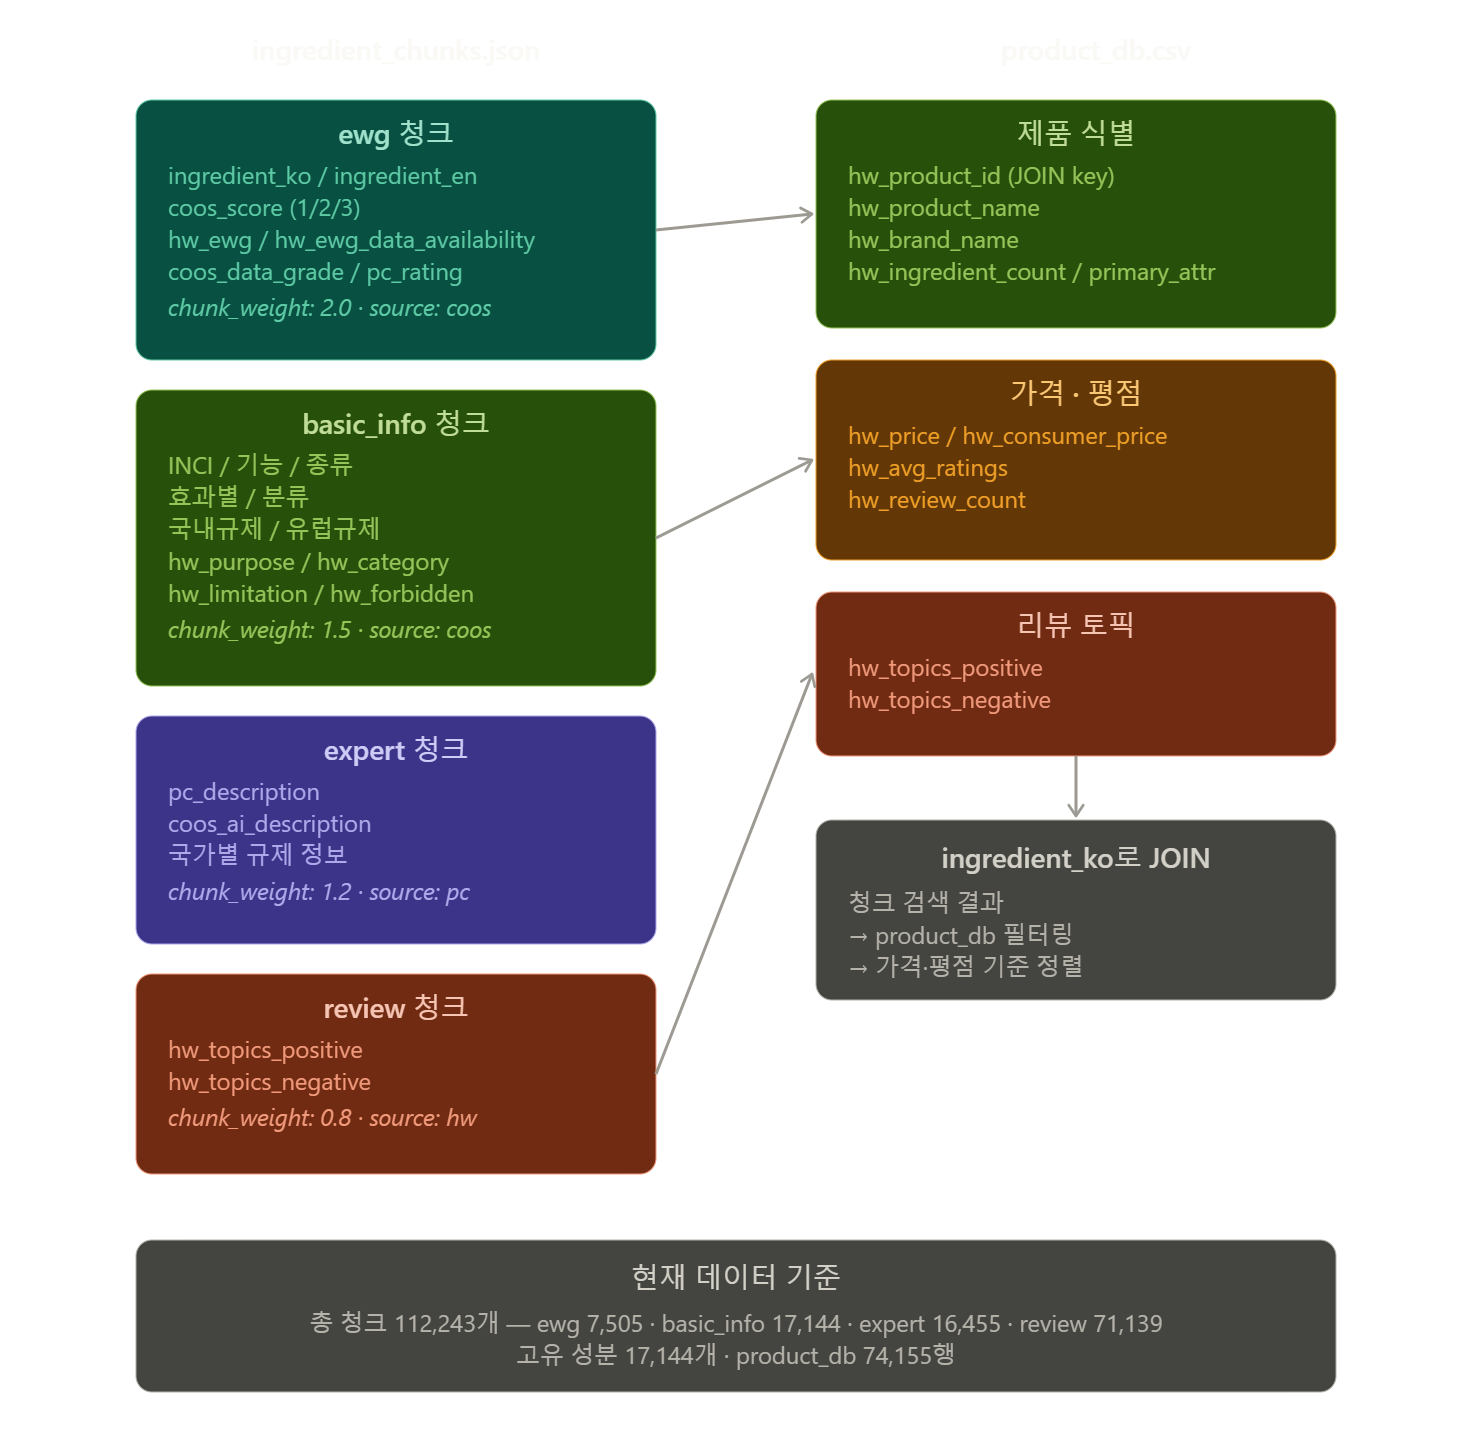

### 청크 변환 파이프라인 — ingredient_merged2.json 기준
- coos_score: 이미 1/2/3으로 정제됨 (기존 [안전]/[주의]/[위험] 텍스트 아님)
- 없어진 컬럼: coos_cas_no, coos_country, hw_ingredient_id, hw_is_allergy, hw_purposes
- product_db.csv: 별도 파일로 이미 존재 (이 스크립트에서 재생성하지 않음)
- 중복 제거: 직접 확인 후 처리할 수 있도록 중복 현황 리포트 출력

In [1]:
import json
import re
import numpy as np
from collections import Counter

In [8]:
# 1. 설정

CHUNK_WEIGHT = {
    "ewg":        1.0,
    "basic_info": 1.0,
    "expert":     1.0,
    "review":     1.0,
}

In [16]:
BASE_PATH = "/content/project"
INPUT_FILE = f"{BASE_PATH}/ingredient_merged2.json"
OUTPUT_CHUNKS = f"{BASE_PATH}/ingredient_chunks.json"

with open(INPUT_FILE, "rb") as f:
    raw = f.read()
if raw[:3] == b'\xef\xbb\xbf':
    raw = raw[3:]
text = raw.decode("utf-8", errors="ignore")
data = json.loads(text)

print(f"총 행 수: {len(data)}")
print(f"컬럼 목록: {list(data[0].keys())}")

총 행 수: 87712
컬럼 목록: ['ingredient_ko', 'ingredient_en', 'pc_rating', 'pc_effect', 'pc_category', 'pc_description', 'coos_function', 'coos_type', 'coos_kr_restricted', 'coos_cn_restricted', 'coos_tw_restricted', 'coos_jp_restricted', 'coos_eu_restricted', 'coos_asean_restricted', 'coos_ai_description', 'coos_score', 'coos_data_grade', 'hw_product_id', 'hw_product_name', 'hw_brand_name', 'hw_avg_ratings', 'hw_review_count', 'hw_price', 'hw_consumer_price', 'hw_primary_attr', 'hw_topics_positive', 'hw_topics_negative', 'hw_ingredient_count', 'hw_ewg', 'hw_ewg_data_availability_text', 'hw_purpose', 'hw_limitation', 'hw_forbidden', 'hw_category']


In [17]:
# 중복 현황 리포트
ing_counts = Counter(row.get("ingredient_ko", "") for row in data)
dup_ingredients = {k: v for k, v in ing_counts.items() if v > 1}

print(f"\n── 중복 현황 ──")
print(f"고유 성분 수: {len(ing_counts)}")
print(f"중복 있는 성분 수: {len(dup_ingredients)}")
print(f"가장 많이 중복되는 성분 TOP 10:")
for name, cnt in sorted(dup_ingredients.items(), key=lambda x: -x[1])[:10]:
    print(f"  {name}: {cnt}회")


── 중복 현황 ──
고유 성분 수: 17144
중복 있는 성분 수: 2393
가장 많이 중복되는 성분 TOP 10:
  정제수: 1642회
  1,2-헥산다이올: 1544회
  부틸렌글라이콜: 1350회
  글리세린: 1273회
  에틸헥실글리세린: 1202회
  티타늄디옥사이드: 878회
  프로판다이올: 787회
  소듐하이알루로네이트: 763회
  토코페롤: 753회
  적색산화철: 743회


In [18]:
# 유효값 필터 함수
def is_valid_value(val) -> bool:
    if val is None:
        return False
    s = str(val).strip()
    if s in ("", "nan", "NaN", "None", "없음", "0"):
        return False
    try:
        if np.isnan(float(s)):
            return False
    except (ValueError, TypeError):
        pass
    return True

In [22]:
def row_to_chunks(row: dict) -> list[dict]:
    chunks = []
    ingredient    = str(row.get("ingredient_ko") or "")
    ingredient_en = str(row.get("ingredient_en") or "")

    base_meta = {
        "ingredient_ko":  ingredient,
        "ingredient_en":  ingredient_en,
        "coos_score":     row.get("coos_score"),
        "hw_ewg":         row.get("hw_ewg"),
        "pc_rating":      row.get("pc_rating"),
    }

    # ── 청크 1: EWG 등급 ──
    ewg_parts = []
    if is_valid_value(row.get("coos_score")):
        score_map = {"1": "안전", "2": "주의", "3": "위험"}
        score_label = score_map.get(str(row["coos_score"]), str(row["coos_score"]))
        ewg_parts.append(f"EWG 스코어: {score_label} ({row['coos_score']}등급)")
    if is_valid_value(row.get("coos_data_grade")):
        ewg_parts.append(f"데이터 등급: {row['coos_data_grade']}")
    if is_valid_value(row.get("hw_ewg")):
        ewg_parts.append(f"화해 EWG: {row['hw_ewg']}")
    if is_valid_value(row.get("hw_ewg_data_availability_text")):
        ewg_parts.append(f"EWG 데이터: {row['hw_ewg_data_availability_text']}")

    if ewg_parts:
        chunks.append({
            "page_content": f"[{ingredient}] " + " / ".join(ewg_parts),
            "metadata": {**base_meta, "chunk_type": "ewg",
                         "chunk_weight": CHUNK_WEIGHT["ewg"], "source": "coos"}
        })

    # ── 청크 2: 성분 기본정보 ──
    basic_parts = []
    for col, label in [
        ("ingredient_en", "INCI"), ("coos_function", "기능"),
        ("coos_type", "종류"), ("coos_kr_restricted", "국내규제"),
        ("coos_eu_restricted", "유럽규제"), ("pc_effect", "효과"),
        ("pc_category", "분류"), ("hw_purpose", "화장품목적"),
        ("hw_limitation", "사용제한"), ("hw_forbidden", "사용금지"),
        ("hw_category", "제품카테고리"),
    ]:
        val = row.get(col)
        if is_valid_value(val):
            basic_parts.append(f"{label}: {val}")

    if basic_parts:
        chunks.append({
            "page_content": f"[{ingredient}] " + " / ".join(basic_parts),
            "metadata": {**base_meta, "chunk_type": "basic_info",
                         "chunk_weight": CHUNK_WEIGHT["basic_info"], "source": "coos"}
        })

    # ── 청크 3: 전문가 설명 ──
    expert_parts = []
    if is_valid_value(row.get("pc_description")):
        expert_parts.append(f"PC 설명: {row['pc_description']}")
    if is_valid_value(row.get("coos_ai_description")):
        expert_parts.append(f"AI 설명: {row['coos_ai_description']}")

    if expert_parts:
        chunks.append({
            "page_content": f"[{ingredient}] " + " | ".join(expert_parts),
            "metadata": {**base_meta, "chunk_type": "expert",
                         "chunk_weight": CHUNK_WEIGHT["expert"], "source": "pc"}
        })

    # ── 청크 4: 리뷰·피부반응 ──
    review_parts = []
    if is_valid_value(row.get("hw_topics_positive")):
        review_parts.append(f"긍정 반응: {row['hw_topics_positive']}")
    if is_valid_value(row.get("hw_topics_negative")):
        review_parts.append(f"부정 반응: {row['hw_topics_negative']}")
    if is_valid_value(row.get("hw_primary_attr")):
        review_parts.append(f"주요속성: {row['hw_primary_attr']}")

    if review_parts:
        chunks.append({
            "page_content": f"[{ingredient}] " + " / ".join(review_parts),
            "metadata": {**base_meta, "chunk_type": "review",
                         "chunk_weight": CHUNK_WEIGHT["review"], "source": "hw"}
        })

    return chunks

print("청크 변환 함수 정의 완료")

청크 변환 함수 정의 완료


In [23]:
# 성분별 최적 행 선택 (값이 가장 많이 채워진 행)
from collections import defaultdict

# 성분별로 행 그룹핑
ingredient_groups = defaultdict(list)
for row in data:
    ingredient_groups[row.get("ingredient_ko", "")].append(row)

# 성분 컬럼 목록 (제품 정보 제외)
ingredient_cols = [
    "ingredient_en", "pc_rating", "pc_effect", "pc_category", "pc_description",
    "coos_function", "coos_type", "coos_kr_restricted", "coos_eu_restricted",
    "coos_ai_description", "coos_score", "coos_data_grade",
    "hw_ewg", "hw_ewg_data_availability_text", "hw_purpose",
    "hw_limitation", "hw_forbidden", "hw_category",
]

# 각 성분에서 유효값이 가장 많은 행 선택
best_rows = {}
for ing, rows in ingredient_groups.items():
    best_row = max(rows, key=lambda r: sum(1 for c in ingredient_cols if is_valid_value(r.get(c))))
    best_rows[ing] = best_row

print(f"성분별 최적 행 선택 완료: {len(best_rows)}개 성분")

성분별 최적 행 선택 완료: 17144개 성분


In [24]:
# 전체 청크 변환
all_chunks = []

# 1) ewg / basic_info / expert → 성분별 최적 행에서 1회만 생성
for ing, best_row in best_rows.items():
    chunks = row_to_chunks(best_row)
    all_chunks.extend([c for c in chunks if c["metadata"]["chunk_type"] != "review"])

# 2) review → 제품별로 다르므로 전부 유지
for row in data:
    chunks = row_to_chunks(row)
    all_chunks.extend([c for c in chunks if c["metadata"]["chunk_type"] == "review"])

print(f"\n── 청크 결과 ──")
print(f"총 청크 수: {len(all_chunks)}")

type_counts = Counter(c["metadata"]["chunk_type"] for c in all_chunks)
print(f"청크 타입별 분포: {dict(type_counts)}")


── 청크 결과 ──
총 청크 수: 112243
청크 타입별 분포: {'basic_info': 17144, 'expert': 16455, 'ewg': 7505, 'review': 71139}


In [25]:
# 저장
with open(OUTPUT_CHUNKS, "w", encoding="utf-8") as f:
    json.dump(all_chunks, f, ensure_ascii=False, indent=2)

print(f"청크 저장 완료: {OUTPUT_CHUNKS}")
print(f"총 청크 수: {len(all_chunks)}")

청크 저장 완료: /content/project/ingredient_chunks.json
총 청크 수: 112243


In [26]:
import random

# 1) 기본 통계
print("══ 기본 통계 ══")
print(f"총 청크 수: {len(all_chunks)}")
type_counts = Counter(c["metadata"]["chunk_type"] for c in all_chunks)
for t, cnt in type_counts.items():
    print(f"  {t}: {cnt}")

# 2) ewg/basic_info/expert 중복 없는지 확인
print("\n══ 성분 청크 중복 검사 ══")
for chunk_type in ["ewg", "basic_info", "expert"]:
    ingredients = [c["metadata"]["ingredient_ko"] for c in all_chunks if c["metadata"]["chunk_type"] == chunk_type]
    dup = {k: v for k, v in Counter(ingredients).items() if v > 1}
    if dup:
        print(f"  ❌ {chunk_type}: 중복 {len(dup)}개 → {list(dup.items())[:3]}")
    else:
        print(f"  ✅ {chunk_type}: 중복 없음 ({len(ingredients)}개)")

# 3) review는 제품별로 다른지 확인 (정제수 샘플)
print("\n══ review 청크 샘플 (정제수) ══")
water_reviews = [c for c in all_chunks if c["metadata"]["chunk_type"] == "review" and c["metadata"]["ingredient_ko"] == "정제수"]
print(f"  정제수 review 수: {len(water_reviews)}")
for r in water_reviews[:3]:
    print(f"  → {r['page_content'][:80]}...")

# 4) 빈 page_content 없는지
empty = [c for c in all_chunks if not c["page_content"].strip()]
print(f"\n══ 빈 청크: {'❌ ' + str(len(empty)) + '개' if empty else '✅ 없음'} ══")

# 5) 랜덤 청크 3개 출력
print("\n══ 랜덤 샘플 3개 ══")
for c in random.sample(all_chunks, 3):
    print(f"  [{c['metadata']['chunk_type']}] {c['page_content'][:100]}")
    print(f"    meta: coos_score={c['metadata']['coos_score']}, hw_ewg={c['metadata']['hw_ewg']}")
    print()

══ 기본 통계 ══
총 청크 수: 112243
  basic_info: 17144
  expert: 16455
  ewg: 7505
  review: 71139

══ 성분 청크 중복 검사 ══
  ✅ ewg: 중복 없음 (7505개)
  ✅ basic_info: 중복 없음 (17144개)
  ✅ expert: 중복 없음 (16455개)

══ review 청크 샘플 (정제수) ══
  정제수 review 수: 1638
  → [정제수] 긍정 반응: 수분있는, 잘발리는, 윤기나는, 밀착잘되는, 자연스러운, 핑크기있는, 묻어나지않는 / 부정 반응: 색감안좋은, 지속력안좋...
  → [정제수] 긍정 반응: 자연스러운, 잘발리는, 가벼운, 톤업되는, 피부톤이개선되는, 톤보정되는, 자극없는 / 부정 반응: 보습안되는, 밀착안되는...
  → [정제수] 긍정 반응: 커버잘되는, 자연스러운, 편안해지는, 답답하지않은, 쫀득한, 각질부각안되는, 뒤집어지지않는 / 부정 반응: 색감안좋은, ...

══ 빈 청크: ✅ 없음 ══

══ 랜덤 샘플 3개 ══
  [basic_info] [다이펩타이드-41니코티네이트] INCI: Dipeptide-41 Nicotinate / 기능: AI Anti-aging/Wrinkle Care AI Conditioning EU 
    meta: coos_score=0, hw_ewg=None

  [ewg] [헥사미딘다이이세티오네이트] EWG 스코어: 안전 (1등급) / 데이터 등급: [ Limited ] 데이터가 충분하지 않음.
    meta: coos_score=1, hw_ewg=None

  [expert] [티아캘러스추출물] AI 설명: 티아캘러스추출물(Gardenia Taitensis Callus Extract)은 피부 진정 및 보습에 도움을 주는 성분으로, 피부 장벽 강화와 항염
    meta: coos_score=0, hw_ewg=None

